# Depression Severity Classification — TDDiff + Bi-Mamba (v3.0)
### Temporal Difference Features · Parallelised Frame Encoder · Bidirectional Mamba Window Encoder

**What changed from v2.0 and why:**

| Area | v2.0 | v3.0 | Motivation |
|---|---|---|---|
| Frame-level features | Raw AU features (49-dim) | **TD-augmented** [f_t \|\| Δf_t] (98-dim) | Explicitly encode inter-frame motion; suppresses static appearance bias; inspired by TDC in PhysMamba |
| Level 1 encoder | Transformer in sequential Python loop (no cross-window gradient flow) | **Fully parallelised** Transformer over all windows simultaneously | Correct gradient flow; ~10× faster training |
| Level 2 encoder | Transformer (quadratic O(W²) over window sequence) | **Bi-Mamba SSM** (linear O(W)) | Efficient long-range behavioral modeling; W can be 100-240 windows per interview |
| Cross-window context | Manual previous-embedding concat (detached) | Implicit via Mamba state propagation | Mamba state carries information forward naturally without detachment |
| External dependencies | None | None | Pure PyTorch Mamba — no mamba_ssm install required |

**Preserved exactly from v2.0:** stratified splits · scaler fitted on train only ·
WeightedRandomSampler · LabelSmoothing CE · EMD ordinal loss · warmup→cosine LR ·
masked mean pooling · per-class F1 tracking · ordinal error analysis


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import gc
import joblib
from pathlib import Path
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.nn.utils.rnn import pad_sequence

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix,
    classification_report, precision_recall_fscore_support,
)

os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [ ]:
# ── Paths ─────────────────────────────────────────────────────────────────────
BASE_DIR      = Path("/content/drive/MyDrive")
PROCESSED_DIR = BASE_DIR / "DAIC_WOZ_VIDEO_BRANCH" / "data" / "processed"
WINDOWS_DIR   = PROCESSED_DIR / "windows_processed"
SAVE_DIR      = BASE_DIR / "DAIC_WOZ_VIDEO_BRANCH" / "results" / "models"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# ── Hyperparameters ────────────────────────────────────────────────────────────
FPS           = 30
WINDOW_SIZE   = 300      # 10 sec @ 30 fps
STRIDE        = 150      # 5 sec overlap
BATCH_SIZE    = 4        # participants per batch
NUM_EPOCHS    = 100
PATIENCE      = 25
LR            = 1e-4
WEIGHT_DECAY  = 1e-4
WARMUP_EPOCHS = 5        # linear warm-up before cosine decay
LABEL_SMOOTH  = 0.1
EMD_WEIGHT    = 0.5      # ordinal EMD auxiliary loss weight

VAL_RATIO     = 0.15
TEST_RATIO    = 0.15
RANDOM_SEED   = 42

NUM_CLASSES   = 5
CLASS_NAMES   = ["Minimal (0-4)", "Mild (5-9)", "Moderate (10-14)",
                 "Mod-Severe (15-19)", "Severe (20-24)"]

DROP_FEATURES = ["frame", "timestamp", "confidence", "success"]

# ── Model hyperparameters ──────────────────────────────────────────────────────
INPUT_SIZE    = 49   # OpenFace AU + pose + gaze features
D_MODEL       = 64   # internal model dimension
NHEAD         = 8    # Transformer attention heads (Level 1)
NUM_FRAME_LAYERS = 2 # Transformer depth for frame-level encoder
D_STATE       = 16   # Mamba SSM state dimension
MAMBA_DEPTH   = 2    # number of Mamba layers (each direction)
DROPOUT       = 0.3
MAX_WIN_FRAMES = 300 # max frames per window (= WINDOW_SIZE)
MAX_WINDOWS   = 512  # max windows per participant

In [ ]:
def phq_to_class(score: float) -> int:
    """PHQ-8 / PHQ-9 severity bucketing (standard clinical thresholds)."""
    if   score <= 4:  return 0   # Minimal
    elif score <= 9:  return 1   # Mild
    elif score <= 14: return 2   # Moderate
    elif score <= 19: return 3   # Moderately Severe
    else:             return 4   # Severe

## Stratified Train / Val / Test Split
Re-derive the split at runtime so each severity class is proportionally represented
in all three subsets. Prevents silent class imbalance from an arbitrary pre-existing split.

In [ ]:
metadata_df = pd.read_csv(WINDOWS_DIR / "metadata.csv")
metadata_df["severity_class"] = metadata_df["phq_score"].apply(phq_to_class)

participant_df = (
    metadata_df
    .groupby("participant_id")
    .first()
    .reset_index()[["participant_id", "phq_score", "severity_class", "window_file"]]
)

print("Total participants:", len(participant_df))
print("\nClass distribution (all):")
print(participant_df["severity_class"].value_counts().sort_index())

# Step 1: hold out test
trainval_df, test_df = train_test_split(
    participant_df, test_size=TEST_RATIO,
    stratify=participant_df["severity_class"], random_state=RANDOM_SEED
)
# Step 2: train / val
val_size_adj = VAL_RATIO / (1 - TEST_RATIO)
train_df, val_df = train_test_split(
    trainval_df, test_size=val_size_adj,
    stratify=trainval_df["severity_class"], random_state=RANDOM_SEED
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"\nAfter stratified split:")
print(f"  Train: {len(train_df)} participants")
print(f"  Val:   {len(val_df)} participants")
print(f"  Test:  {len(test_df)} participants")

for name, df in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    counts = df["severity_class"].value_counts().sort_index()
    pcts   = (counts / len(df) * 100).round(1)
    print(f"\n{name} class distribution:")
    for cls, cnt in counts.items():
        print(f"  Class {cls} ({CLASS_NAMES[cls]}): {cnt} ({pcts[cls]}%)")

Total participants: 219

Class distribution (all):
severity_class
0    103
1     51
2     34
3     23
4      8
Name: count, dtype: int64

After stratified split:
  Train: 153 participants
  Val:   33 participants
  Test:  33 participants

Train class distribution:
  Class 0 (Minimal (0-4)): 72 (47.1%)
  Class 1 (Mild (5-9)): 35 (22.9%)
  Class 2 (Moderate (10-14)): 24 (15.7%)
  Class 3 (Mod-Severe (15-19)): 16 (10.5%)
  Class 4 (Severe (20-24)): 6 (3.9%)

Val class distribution:
  Class 0 (Minimal (0-4)): 15 (45.5%)
  Class 1 (Mild (5-9)): 8 (24.2%)
  Class 2 (Moderate (10-14)): 5 (15.2%)
  Class 3 (Mod-Severe (15-19)): 4 (12.1%)
  Class 4 (Severe (20-24)): 1 (3.0%)

Test class distribution:
  Class 0 (Minimal (0-4)): 16 (48.5%)
  Class 1 (Mild (5-9)): 8 (24.2%)
  Class 2 (Moderate (10-14)): 5 (15.2%)
  Class 3 (Mod-Severe (15-19)): 3 (9.1%)
  Class 4 (Severe (20-24)): 1 (3.0%)


## Fit Scaler on Training Set Only
Fitting **after** the stratified split guarantees zero leakage from val/test
statistics into the normalization parameters.

In [ ]:
scaler = StandardScaler()

for _, row in train_df.iterrows():
    windows = np.load(row["window_file"])          # (W, T, F)
    frames  = windows.reshape(-1, windows.shape[-1])
    scaler.partial_fit(frames)

print(f"Scaler fitted on {len(train_df)} train participants.")
print(f"Feature dim: {scaler.n_features_in_}")

joblib.dump(scaler, PROCESSED_DIR / "scaler_stratified_v3.pkl")
print("Scaler saved.")

del frames
gc.collect()

Scaler fitted on 153 train participants.
Feature dim: 49
Scaler saved.


591

## Dataset, Collation & Weighted Sampling
`WeightedRandomSampler` oversamples under-represented severity classes so the
model sees a roughly balanced class distribution per epoch, complementing the
weighted CE loss.

In [ ]:
class ParticipantDataset(Dataset):
    """One sample = one participant (all their 10-sec windows)."""
    def __init__(self, metadata_df: pd.DataFrame, scaler: StandardScaler):
        self.metadata = metadata_df.reset_index(drop=True)
        self.scaler   = scaler

    def __len__(self):
        return len(self.metadata)

    def __getitem__(self, idx):
        row     = self.metadata.iloc[idx]
        raw     = np.load(row["window_file"])          # (W, T, F)
        W, T, Fv = raw.shape
        scaled  = (
            self.scaler
            .transform(raw.reshape(-1, Fv), copy=False)
            .reshape(W, T, Fv)
            .astype(np.float32, copy=False)
        )
        return {
            "windows":        torch.from_numpy(scaled),
            "severity_class": torch.tensor(row["severity_class"], dtype=torch.long),
            "participant_id": row["participant_id"],
        }


def participant_collate(batch):
    """Pad variable-length window sequences for batching."""
    windows     = [x["windows"] for x in batch]
    num_windows = torch.tensor([w.shape[0] for w in windows])
    padded      = pad_sequence(windows, batch_first=True)  # (B, W_max, T, F)
    return {
        "windows":        padded,
        "num_windows":    num_windows,
        "severity_class": torch.stack([x["severity_class"] for x in batch]),
        "participant_id": [x["participant_id"] for x in batch],
    }


# ── Load scaler and build datasets ────────────────────────────────────────────
scaler = joblib.load(PROCESSED_DIR / "scaler_stratified_v3.pkl")

train_dataset = ParticipantDataset(train_df, scaler)
val_dataset   = ParticipantDataset(val_df,   scaler)
test_dataset  = ParticipantDataset(test_df,  scaler)

# ── WeightedRandomSampler ─────────────────────────────────────────────────────
train_labels      = train_df["severity_class"].values
class_counts      = np.bincount(train_labels, minlength=NUM_CLASSES)
class_weights_arr = 1.0 / (class_counts + 1e-6)
sample_weights    = class_weights_arr[train_labels]
sampler = WeightedRandomSampler(
    weights     = torch.from_numpy(sample_weights).float(),
    num_samples = len(train_dataset),
    replacement = True,
)

# ── DataLoaders ───────────────────────────────────────────────────────────────
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler,
                          collate_fn=participant_collate, drop_last=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          collate_fn=participant_collate)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          collate_fn=participant_collate)

batch = next(iter(train_loader))
print("windows shape:   ", batch["windows"].shape)    # (B, W_max, T, F)
print("num_windows:     ", batch["num_windows"])
print("severity_class:  ", batch["severity_class"])

windows shape:    torch.Size([4, 215, 300, 49])
num_windows:      tensor([155, 192, 155, 215])
severity_class:   tensor([4, 1, 4, 2])


## Model Architecture — DepressionMambaNet

```
Input (B, W_max, T=300, F=49)
        │
        ▼  ── vectorised over all (B × W_max) windows simultaneously ──────────
  ┌──────────────────────────────────────────────────────────────────────────┐
  │  Temporal Difference Augmentation                                        │
  │                                                                          │
  │  Δf_t = f_t − f_{t−1}   (pad t=0 with zeros)                            │
  │  input_aug = [f_t ‖ Δf_t]   →   (B, W, T, 98)                           │
  │                                                                          │
  │  Motivation: explicitly encode inter-frame motion dynamics.              │
  │  Analogous to Temporal Difference Convolution (TDC) in PhysMamba,       │
  │  but applied to AU feature vectors rather than raw pixels.               │
  └──────────────────────────────────────────────────────────────────────────┘
        │ reshape → (B×W, T, 98)
        ▼
  ┌──────────────────────────────────────────────────────────────────────────┐
  │  Level 1 — Frame Encoder  (shared weights, all windows in parallel)     │
  │                                                                          │
  │  Linear(98 → d_model=64)                                                 │
  │  + learnable positional embedding (per frame)                            │
  │  Transformer Encoder  [2 layers, 8 heads, d_ff=256]                     │
  │  Additive Attention   →  window_emb  (B×W, 64)                           │
  │  reshape              →  (B, W, 64)                                      │
  │                                                                          │
  │  Note: fully vectorised — gradients flow through ALL windows.            │
  └──────────────────────────────────────────────────────────────────────────┘
        │  (B, W_max, 64)
        ▼
  ┌──────────────────────────────────────────────────────────────────────────┐
  │  Level 2 — Bidirectional Mamba Window Encoder                           │
  │                                                                          │
  │  Linear(64 → 64) + learnable positional embedding (per window)          │
  │  Forward Mamba  [2 layers]  →  fwd_out  (B, W, 64)                      │
  │  Backward Mamba [2 layers]  →  bwd_out  (B, W, 64)                      │
  │  Sum + LayerNorm            →  (B, W, 64)  [padding zeroed]              │
  │  Additive Attention (padding-masked)  →  participant_emb  (B, 64)        │
  │                                                                          │
  │  Note: O(W) complexity vs O(W²) for Transformer.                        │
  │  Mamba state propagates behavioral context across the interview.         │
  └──────────────────────────────────────────────────────────────────────────┘
        │  (B, 64)
        ▼
  FC(64→128) → LayerNorm → GELU → Dropout(0.3) → FC(128→5) → logits
```


In [ ]:
# ── Mamba SSM Block (pure PyTorch — no external mamba_ssm required) ─────────

class MambaBlock(nn.Module):
    """
    Single Mamba SSM layer.

    Implements a simplified but faithful Mamba block:
      - Input-dependent selective scan (S6 mechanism)
      - 1D depthwise conv for local context
      - Gated output with SiLU
      - Residual connection + LayerNorm

    Input / output shape: (B, L, d_model)
    """
    def __init__(self, d_model: int, d_state: int = 16, expand: int = 2, dropout: float = 0.1):
        super().__init__()
        self.d_model = d_model
        self.d_state = d_state
        self.d_inner = d_model * expand

        self.in_proj  = nn.Linear(d_model, self.d_inner * 2, bias=False)
        self.conv1d   = nn.Conv1d(self.d_inner, self.d_inner, kernel_size=3,
                                   padding=1, groups=self.d_inner, bias=True)
        # Projects x → (B, C, delta_raw) + (B, N) + (B, N)
        self.x_proj   = nn.Linear(self.d_inner, d_state * 2 + self.d_inner, bias=False)
        self.dt_proj  = nn.Linear(self.d_inner, self.d_inner, bias=True)

        # A: log-initialized HiPPO-style (stable gradients)
        A = torch.arange(1, d_state + 1, dtype=torch.float32).unsqueeze(0).expand(self.d_inner, -1)
        self.A_log = nn.Parameter(torch.log(A))
        self.D     = nn.Parameter(torch.ones(self.d_inner))

        self.out_proj = nn.Linear(self.d_inner, d_model, bias=False)
        self.norm     = nn.LayerNorm(d_model)
        self.dropout  = nn.Dropout(dropout)

    def _selective_scan(self, x: torch.Tensor) -> torch.Tensor:
        """Discretized SSM scan. x: (B, L, d_inner) → (B, L, d_inner)"""
        B, L, D = x.shape
        N = self.d_state

        x_proj     = self.x_proj(x)                          # (B, L, D+2N)
        delta_raw, B_proj, C_proj = x_proj.split([D, N, N], dim=-1)

        delta = F.softplus(self.dt_proj(delta_raw))           # (B, L, D)
        A     = -torch.exp(self.A_log.float())                # (D, N)

        # Discretize A and B
        dA = torch.exp(delta.unsqueeze(-1) * A[None, None])   # (B, L, D, N)
        dB = delta.unsqueeze(-1) * B_proj.unsqueeze(2)        # (B, L, D, N)

        # Sequential scan over time dimension
        h  = torch.zeros(B, D, N, device=x.device, dtype=x.dtype)
        ys = []
        for t in range(L):
            h = dA[:, t] * h + dB[:, t] * x[:, t, :, None]  # (B, D, N)
            y = (h * C_proj[:, t, None, :]).sum(-1)           # (B, D)
            ys.append(y)

        y = torch.stack(ys, dim=1)                            # (B, L, D)
        y = y + x * self.D[None, None]                        # skip connection (D term)
        return y

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        residual = x
        xz       = self.in_proj(x)                            # (B, L, 2*d_inner)
        x_in, z  = xz.chunk(2, dim=-1)

        x_in = F.silu(self.conv1d(x_in.transpose(1, 2)).transpose(1, 2))
        y    = self._selective_scan(x_in)
        y    = y * F.silu(z)
        out  = self.out_proj(y)
        return self.norm(self.dropout(out) + residual)


class BiMambaEncoder(nn.Module):
    """
    Bidirectional Mamba encoder.

    Runs two independent Mamba stacks — one forward, one backward over the
    reversed sequence — then sums their outputs. This gives the model access
    to both past and future behavioral context at every window position,
    analogous to BiLSTM but with linear-time complexity.

    Input / output: (B, L, d_model)
    pad_mask: (B, L) bool, True = padding position (zeroed in output)
    """
    def __init__(self, d_model: int, d_state: int = 16, depth: int = 2, dropout: float = 0.1):
        super().__init__()
        self.fwd_layers = nn.ModuleList([
            MambaBlock(d_model, d_state, dropout=dropout) for _ in range(depth)
        ])
        self.bwd_layers = nn.ModuleList([
            MambaBlock(d_model, d_state, dropout=dropout) for _ in range(depth)
        ])
        self.out_norm = nn.LayerNorm(d_model)

    def forward(self, x: torch.Tensor, pad_mask=None) -> torch.Tensor:
        fwd = x
        for layer in self.fwd_layers:
            fwd = layer(fwd)

        bwd = torch.flip(x, dims=[1])
        for layer in self.bwd_layers:
            bwd = layer(bwd)
        bwd = torch.flip(bwd, dims=[1])

        out = self.out_norm(fwd + bwd)

        if pad_mask is not None:
            out = out.masked_fill(pad_mask.unsqueeze(-1), 0.0)
        return out


class AdditiveAttention(nn.Module):
    """
    Bahdanau-style additive attention.
    Collapses (B, L, D) → context vector (B, D).
    pad_mask: (B, L) bool, True = padding → masked out before softmax.
    """
    def __init__(self, hidden_dim: int):
        super().__init__()
        self.W = nn.Linear(hidden_dim, hidden_dim, bias=False)
        self.v = nn.Linear(hidden_dim, 1,          bias=False)

    def forward(self, x: torch.Tensor, mask=None) -> torch.Tensor:
        scores  = self.v(torch.tanh(self.W(x))).squeeze(-1)  # (B, L)
        if mask is not None:
            scores = scores.masked_fill(mask, float("-inf"))
        weights = torch.nan_to_num(torch.softmax(scores, dim=-1), nan=0.0)
        return (x * weights.unsqueeze(-1)).sum(dim=1)         # (B, D)


class DepressionMambaNet(nn.Module):
    """
    Depression severity classifier — v3.0.

    Architecture:
      Level 1  Temporal difference augmentation + Transformer frame encoder
               (fully parallelised over all windows)
      Level 2  Bidirectional Mamba SSM over window sequence
               (replaces v2 quadratic window Transformer)

    Key correctness improvements over v2:
      - No Python loop over windows: all (B × W) windows processed in one
        batched Transformer call → proper gradient flow everywhere
      - Temporal difference [f_t ‖ Δf_t] replaces manual context concat,
        giving explicit motion signal without detached embeddings
      - Bi-Mamba is O(W) in window count vs O(W²) for Transformer
    """
    def __init__(
        self,
        input_size:       int   = 49,
        d_model:          int   = 64,
        num_frame_layers: int   = 2,
        d_state:          int   = 16,
        mamba_depth:      int   = 2,
        dropout:          float = 0.3,
        num_classes:      int   = 5,
        nhead:            int   = 8,
        max_window_frames: int  = 300,
        max_windows:      int   = 512,
    ):
        super().__init__()
        self.d_model = d_model

        # ── Level 1: Frame encoder ─────────────────────────────────────────────
        # Input is [f_t ‖ Δf_t] so dimension doubles
        self.frame_proj = nn.Linear(input_size * 2, d_model)
        frame_enc_layer = nn.TransformerEncoderLayer(
            d_model        = d_model,
            nhead          = nhead,
            dim_feedforward = d_model * 4,
            dropout        = dropout,
            activation     = "gelu",
            batch_first    = True,
        )
        self.frame_transformer = nn.TransformerEncoder(frame_enc_layer, num_layers=num_frame_layers)
        self.frame_pos_emb     = nn.Parameter(torch.zeros(max_window_frames, d_model))
        self.frame_attn        = AdditiveAttention(d_model)

        # ── Level 2: Bi-Mamba window encoder ──────────────────────────────────
        self.window_proj    = nn.Linear(d_model, d_model)
        self.window_pos_emb = nn.Parameter(torch.zeros(max_windows, d_model))
        self.bi_mamba       = BiMambaEncoder(d_model, d_state, mamba_depth, dropout)
        self.window_attn    = AdditiveAttention(d_model)

        # ── Classifier ─────────────────────────────────────────────────────────
        self.classifier = nn.Sequential(
            nn.Linear(d_model, 128),
            nn.LayerNorm(128),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

        # Initialise positional embeddings with small noise
        nn.init.normal_(self.frame_pos_emb,  std=0.02)
        nn.init.normal_(self.window_pos_emb, std=0.02)

    # ─────────────────────────────────────────────────────────────────────────
    def forward(self, windows: torch.Tensor, num_windows: torch.Tensor) -> torch.Tensor:
        """
        windows:     (B, W_max, T, F)   — scaled OpenFace features
        num_windows: (B,)               — actual window count per participant
        returns:     (B, num_classes)   — logits
        """
        B, W, T, Fv = windows.shape
        dev = windows.device

        # ── Temporal difference augmentation ──────────────────────────────────
        # Δf_t = f_t - f_{t-1}; pad position 0 with zeros so shape is unchanged
        diff = torch.cat([
            torch.zeros(B, W, 1, Fv, device=dev, dtype=windows.dtype),
            windows[:, :, 1:, :] - windows[:, :, :-1, :],
        ], dim=2)                                              # (B, W, T, F)
        frames_aug = torch.cat([windows, diff], dim=-1)       # (B, W, T, 2F)

        # ── Level 1: Parallelised frame encoder ───────────────────────────────
        # Flatten (B, W) into a single batch dimension so all windows are
        # processed in one Transformer call — no loop, correct gradient flow.
        frames_flat = frames_aug.view(B * W, T, Fv * 2)       # (B*W, T, 2F)
        x = self.frame_proj(frames_flat)                       # (B*W, T, D)
        if T <= self.frame_pos_emb.shape[0]:
            frame_pos = self.frame_pos_emb[:T].unsqueeze(0)
        else:
            frame_pos = F.interpolate(
                self.frame_pos_emb.T.unsqueeze(0),
                size=T, mode='linear', align_corners=False
            ).squeeze(0).T.unsqueeze(0)
        x = x + frame_pos
        x = self.frame_transformer(x)                          # (B*W, T, D)
        win_embs = self.frame_attn(x)                          # (B*W, D)
        win_embs = win_embs.view(B, W, self.d_model)           # (B, W, D)

        # ── Padding mask: True = this window is padding ────────────────────────
        pad_mask = (
            torch.arange(W, device=dev).unsqueeze(0)
            >= num_windows.unsqueeze(1).to(dev)
        )  # (B, W)

        # Zero out embeddings for padding windows before Mamba
        win_embs = win_embs.masked_fill(pad_mask.unsqueeze(-1), 0.0)

        # ── Level 2: Bi-Mamba window encoder ──────────────────────────────────
        wout = self.window_proj(win_embs)
        # Dynamic pos emb: if W exceeds pre-allocated size, interpolate
        if W <= self.window_pos_emb.shape[0]:
            win_pos = self.window_pos_emb[:W].unsqueeze(0)
        else:
            win_pos = F.interpolate(
                self.window_pos_emb.T.unsqueeze(0),  # (1, D, MAX_W)
                size=W, mode='linear', align_corners=False
            ).squeeze(0).T.unsqueeze(0)              # (1, W, D)
        wout = wout + win_pos
        wout = self.bi_mamba(wout, pad_mask=pad_mask)          # (B, W, D)

        # Masked attention pool → participant embedding
        part_emb = self.window_attn(wout, mask=pad_mask)       # (B, D)
        return self.classifier(part_emb)                       # (B, num_classes)


# ── Sanity check ──────────────────────────────────────────────────────────────
print("Initialising DepressionMambaNet v3.0 ...")
_model = DepressionMambaNet(
    input_size=INPUT_SIZE, d_model=D_MODEL, nhead=NHEAD,
    num_frame_layers=NUM_FRAME_LAYERS, d_state=D_STATE,
    mamba_depth=MAMBA_DEPTH, dropout=DROPOUT, num_classes=NUM_CLASSES,
).to(device)

_B, _W, _T, _F = 2, 10, WINDOW_SIZE, INPUT_SIZE
_dummy = torch.randn(_B, _W, _T, _F).to(device)
_nw    = torch.tensor([8, 6])
_out   = _model(_dummy, _nw)
assert _out.shape == (_B, NUM_CLASSES), f"Unexpected output shape: {_out.shape}"
print(f"  ✓ Output shape: {_out.shape}")

total_params = sum(p.numel() for p in _model.parameters() if p.requires_grad)
print(f"  ✓ Trainable parameters: {total_params:,}")

# Verify gradients flow through all parameters
_loss = F.cross_entropy(_out, torch.zeros(_B, dtype=torch.long).to(device))
_loss.backward()
all_grads = all(p.grad is not None for p in _model.parameters() if p.requires_grad)
print(f"  ✓ All gradients flow: {all_grads}")

del _model, _dummy, _out, _loss
torch.cuda.empty_cache()

Initialising DepressionMambaNet v3.0 ...
  ✓ Output shape: torch.Size([2, 5])
  ✓ Trainable parameters: 437,637
  ✓ All gradients flow: True


## Loss Functions

Two complementary losses:

1. **Label-smoothed Cross-Entropy** — prevents over-confident predictions on the majority class; improves calibration on imbalanced data.

2. **Earth Mover's Distance (EMD) auxiliary loss** — penalises predictions that are far from the true ordinal class. A prediction of class 4 when the true class is 0 incurs a much larger penalty than class 1 vs class 0. Exploits the natural PHQ severity ordering.


In [ ]:
class LabelSmoothingCE(nn.Module):
    """Cross-entropy with uniform label smoothing."""
    def __init__(self, num_classes: int, smoothing: float = 0.1, weight=None):
        super().__init__()
        self.smoothing   = smoothing
        self.num_classes = num_classes
        self.weight      = weight

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        log_probs = F.log_softmax(logits, dim=-1)
        with torch.no_grad():
            smooth_labels = torch.full_like(log_probs, self.smoothing / (self.num_classes - 1))
            smooth_labels.scatter_(1, targets.unsqueeze(1), 1.0 - self.smoothing)
        if self.weight is not None:
            w    = self.weight[targets]
            loss = -(smooth_labels * log_probs).sum(dim=-1) * w
            return loss.mean()
        return -(smooth_labels * log_probs).sum(dim=-1).mean()


def ordinal_emd_loss(logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
    """
    Earth Mover's Distance ordinal loss.
    L1 distance between cumulative predicted probs and cumulative one-hot target.
    Penalises predictions that are ordinally distant from the true class.
    """
    num_classes = logits.size(1)
    probs       = torch.softmax(logits, dim=-1)
    cum_pred    = torch.cumsum(probs, dim=-1)
    cum_target  = torch.cumsum(F.one_hot(targets, num_classes).float(), dim=-1)
    return torch.mean(torch.abs(cum_pred - cum_target))


# ── Class weights from training split ─────────────────────────────────────────
cw = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_CLASSES),
    y=train_df["severity_class"].values,
)
cw = np.sqrt(cw)    # sqrt-dampen to avoid extreme upweighting of rare classes
class_weight_tensor = torch.tensor(cw, dtype=torch.float32).to(device)
print("Class weights (sqrt-balanced):", class_weight_tensor.cpu().numpy().round(3))

cls_criterion = LabelSmoothingCE(
    num_classes=NUM_CLASSES,
    smoothing=LABEL_SMOOTH,
    weight=class_weight_tensor,
)

Class weights (sqrt-balanced): [0.652 0.935 1.129 1.383 2.258]


In [ ]:
def get_scheduler(optimizer, warmup_epochs: int, total_epochs: int):
    """Linear warm-up then cosine annealing."""
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return float(epoch + 1) / warmup_epochs
        progress = (epoch - warmup_epochs) / max(1, total_epochs - warmup_epochs)
        return 0.5 * (1.0 + np.cos(np.pi * progress))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0.0
    all_preds, all_labels = [], []

    for batch in loader:
        windows     = batch["windows"].to(device)
        num_windows = batch["num_windows"]
        labels      = batch["severity_class"].to(device)

        optimizer.zero_grad()
        logits   = model(windows, num_windows)
        ce_loss  = cls_criterion(logits, labels)
        emd_loss = ordinal_emd_loss(logits, labels)
        loss     = ce_loss + EMD_WEIGHT * emd_loss

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        all_preds.extend(logits.argmax(dim=1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    return (
        total_loss / len(loader),
        accuracy_score(all_labels, all_preds),
        f1_score(all_labels, all_preds, average="macro", zero_division=0),
    )


@torch.no_grad()
def evaluate(model, loader, device, return_arrays: bool = False):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []

    for batch in loader:
        windows     = batch["windows"].to(device)
        num_windows = batch["num_windows"]
        labels      = batch["severity_class"].to(device)

        logits   = model(windows, num_windows)
        ce_loss  = cls_criterion(logits, labels)
        emd_loss = ordinal_emd_loss(logits, labels)
        total_loss += (ce_loss + EMD_WEIGHT * emd_loss).item()

        all_preds.extend(logits.argmax(dim=1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    metrics = {
        "loss":         total_loss / len(loader),
        "acc":          accuracy_score(all_labels, all_preds),
        "macro_f1":     f1_score(all_labels, all_preds, average="macro",    zero_division=0),
        "w_f1":         f1_score(all_labels, all_preds, average="weighted", zero_division=0),
        "per_class_f1": f1_score(all_labels, all_preds, average=None,
                                  labels=list(range(NUM_CLASSES)), zero_division=0),
    }
    if return_arrays:
        metrics["preds"]  = np.array(all_preds)
        metrics["labels"] = np.array(all_labels)
    return metrics

## Training

In [ ]:
model = DepressionMambaNet(
    input_size       = INPUT_SIZE,
    d_model          = D_MODEL,
    nhead            = NHEAD,
    num_frame_layers = NUM_FRAME_LAYERS,
    d_state          = D_STATE,
    mamba_depth      = MAMBA_DEPTH,
    dropout          = DROPOUT,
    num_classes      = NUM_CLASSES,
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = get_scheduler(optimizer, WARMUP_EPOCHS, NUM_EPOCHS)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {total_params:,}")
print(f"Device: {device}  |  Train: {len(train_dataset)}  |  Val: {len(val_dataset)}")

best_val_f1      = 0.0
patience_counter = 0
history          = []
BEST_MODEL_PATH  = SAVE_DIR / "best_depression_mamba_v3.pt"

print("\n" + "=" * 85)
print(f"{'Ep':>4} | {'TrLoss':>8} {'TrF1':>7} | {'VlLoss':>8} {'VlAcc':>7} {'VlMF1':>7} | {'LR':>9} | Note")
print("=" * 85)

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc, tr_f1 = train_one_epoch(model, train_loader, optimizer, device)
    val_m = evaluate(model, val_loader, device)
    scheduler.step()

    cur_lr = optimizer.param_groups[0]["lr"]
    note   = ""

    history.append({
        "epoch":    epoch,
        "tr_loss":  tr_loss,
        "tr_f1":    tr_f1,
        "val_loss": val_m["loss"],
        "val_acc":  val_m["acc"],
        "val_f1":   val_m["macro_f1"],
        "val_wf1":  val_m["w_f1"],
        "lr":       cur_lr,
    })

    if val_m["macro_f1"] > best_val_f1:
        best_val_f1      = val_m["macro_f1"]
        patience_counter = 0
        torch.save({
            "epoch":            epoch,
            "model_state_dict": model.state_dict(),
            "model_config": {
                "input_size":       INPUT_SIZE,
                "d_model":          D_MODEL,
                "nhead":            NHEAD,
                "num_frame_layers": NUM_FRAME_LAYERS,
                "d_state":          D_STATE,
                "mamba_depth":      MAMBA_DEPTH,
                "dropout":          DROPOUT,
                "num_classes":      NUM_CLASSES,
            },
            "scaler_mean":  torch.tensor(scaler.mean_,  dtype=torch.float32),
            "scaler_scale": torch.tensor(scaler.scale_, dtype=torch.float32),
            "best_val_f1":  best_val_f1,
            "label_map":    {i: n for i, n in enumerate(CLASS_NAMES)},
        }, BEST_MODEL_PATH)
        note = f"✓ best F1={best_val_f1:.4f}"
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch}.")
            break

    print(
        f"{epoch:4d} | {tr_loss:8.4f} {tr_f1:7.4f} | "
        f"{val_m['loss']:8.4f} {val_m['acc']:7.4f} {val_m['macro_f1']:7.4f} | "
        f"{cur_lr:9.2e} | {note}"
    )

print(f"\nBest Val Macro-F1: {best_val_f1:.4f}")

Trainable parameters: 437,637
Device: cuda  |  Train: 153  |  Val: 33

  Ep |   TrLoss    TrF1 |   VlLoss   VlAcc   VlMF1 |        LR | Note
   1 |   2.4465  0.1170 |   1.6998  0.1515  0.1194 |  4.00e-05 | ✓ best F1=0.1194
   2 |   2.2696  0.1942 |   1.7090  0.1212  0.0989 |  6.00e-05 | 
   3 |   2.0011  0.2373 |   1.6862  0.1515  0.1132 |  8.00e-05 | 
   4 |   1.9241  0.3984 |   1.7272  0.1212  0.0917 |  1.00e-04 | 
   5 |   1.8018  0.4382 |   1.7349  0.1212  0.1004 |  1.00e-04 | 
   6 |   1.6830  0.4577 |   1.7019  0.1818  0.0889 |  1.00e-04 | 
   7 |   1.5420  0.5139 |   1.7411  0.1212  0.0972 |  9.99e-05 | 
   8 |   1.5491  0.5503 |   1.7491  0.1515  0.0870 |  9.98e-05 | 
   9 |   1.4983  0.5038 |   1.7987  0.2121  0.1624 |  9.96e-05 | ✓ best F1=0.1624
  10 |   1.4516  0.6130 |   1.8096  0.2727  0.2044 |  9.93e-05 | ✓ best F1=0.2044
  11 |   1.3045  0.6803 |   1.8522  0.1212  0.0978 |  9.90e-05 | 
  12 |   1.2572  0.6606 |   1.8659  0.1515  0.1105 |  9.87e-05 | 
  13 |   1.1743  0.

## Training Curves

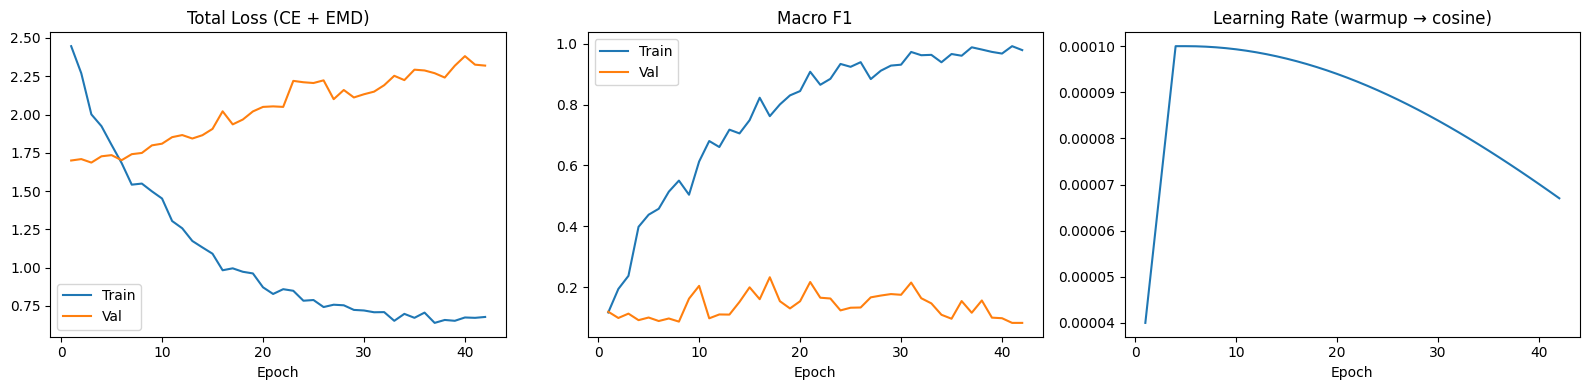

In [ ]:
hist = pd.DataFrame(history)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(hist["epoch"], hist["tr_loss"],  label="Train")
axes[0].plot(hist["epoch"], hist["val_loss"], label="Val")
axes[0].set_title("Total Loss (CE + EMD)"); axes[0].legend(); axes[0].set_xlabel("Epoch")

axes[1].plot(hist["epoch"], hist["tr_f1"],  label="Train")
axes[1].plot(hist["epoch"], hist["val_f1"], label="Val")
axes[1].set_title("Macro F1"); axes[1].legend(); axes[1].set_xlabel("Epoch")

axes[2].plot(hist["epoch"], hist["lr"])
axes[2].set_title("Learning Rate (warmup → cosine)"); axes[2].set_xlabel("Epoch")

plt.tight_layout()
plt.savefig("training_curves_v3.png", dpi=130)
plt.show()

## Evaluation on Test Set

In [ ]:
bundle = torch.load(BEST_MODEL_PATH, map_location=device, weights_only=False)
model  = DepressionMambaNet(**bundle["model_config"]).to(device)
model.load_state_dict(bundle["model_state_dict"])
print(f"Loaded checkpoint from epoch {bundle['epoch']}  |  "
      f"Best val macro-F1: {bundle['best_val_f1']:.4f}")

test_m = evaluate(model, test_loader, device, return_arrays=True)

print("\n" + "=" * 55)
print("TEST RESULTS  (participant-level, stratified split)")
print("=" * 55)
print(f"  Accuracy:        {test_m['acc']:.4f}")
print(f"  Macro F1:        {test_m['macro_f1']:.4f}")
print(f"  Weighted F1:     {test_m['w_f1']:.4f}")
print("\nPer-class F1:")
for i, (name, f1_val) in enumerate(zip(CLASS_NAMES, test_m["per_class_f1"])):
    print(f"  [{i}] {name:<22}: {f1_val:.4f}")

Loaded checkpoint from epoch 17  |  Best val macro-F1: 0.2327

TEST RESULTS  (participant-level, stratified split)
  Accuracy:        0.3636
  Macro F1:        0.3437
  Weighted F1:     0.3767

Per-class F1:
  [0] Minimal (0-4)         : 0.5185
  [1] Mild (5-9)            : 0.2667
  [2] Moderate (10-14)      : 0.2667
  [3] Mod-Severe (15-19)    : 0.0000
  [4] Severe (20-24)        : 0.6667


In [ ]:
print("\nDetailed Classification Report:")
print(classification_report(
    test_m["labels"], test_m["preds"],
    target_names=CLASS_NAMES, digits=4, zero_division=0
))


Detailed Classification Report:
                    precision    recall  f1-score   support

     Minimal (0-4)     0.6364    0.4375    0.5185        16
        Mild (5-9)     0.2857    0.2500    0.2667         8
  Moderate (10-14)     0.2000    0.4000    0.2667         5
Mod-Severe (15-19)     0.0000    0.0000    0.0000         3
    Severe (20-24)     0.5000    1.0000    0.6667         1

          accuracy                         0.3636        33
         macro avg     0.3244    0.4175    0.3437        33
      weighted avg     0.4233    0.3636    0.3767        33



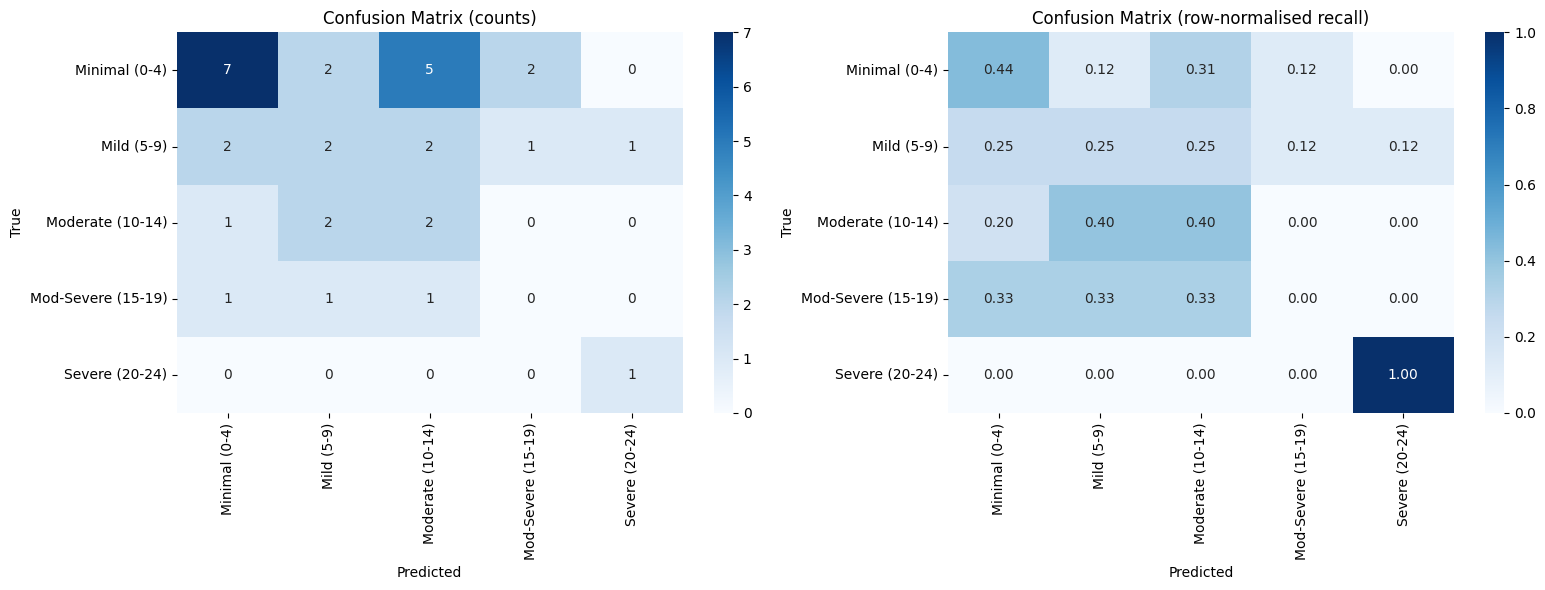

In [ ]:
cm      = confusion_matrix(test_m["labels"], test_m["preds"], labels=list(range(NUM_CLASSES)))
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(cm,      annot=True, fmt="d",   cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_title("Confusion Matrix (counts)")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")

sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1,
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1])
axes[1].set_title("Confusion Matrix (row-normalised recall)")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")

plt.tight_layout()
plt.savefig("confusion_matrix_v3.png", dpi=130)
plt.show()

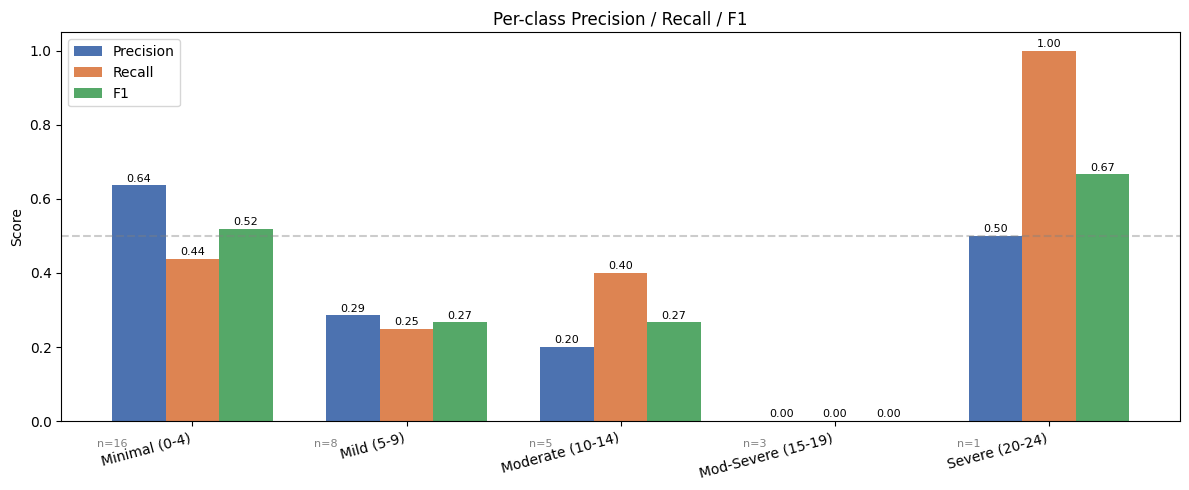

In [ ]:
precision, recall, f1_scores, support = precision_recall_fscore_support(
    test_m["labels"], test_m["preds"],
    labels=list(range(NUM_CLASSES)), zero_division=0
)

x_pos = np.arange(NUM_CLASSES); w = 0.25
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x_pos - w, precision,  w, label="Precision", color="#4C72B0")
ax.bar(x_pos,     recall,     w, label="Recall",    color="#DD8452")
ax.bar(x_pos + w, f1_scores,  w, label="F1",        color="#55A868")
ax.set_xticks(x_pos); ax.set_xticklabels(CLASS_NAMES, rotation=15, ha="right")
ax.set_ylabel("Score"); ax.set_title("Per-class Precision / Recall / F1")
ax.set_ylim(0, 1.05); ax.legend()
ax.axhline(0.5, linestyle="--", color="grey", alpha=0.4)

for i, (p, r, f, s) in enumerate(zip(precision, recall, f1_scores, support)):
    ax.text(i - w,     p + 0.01, f"{p:.2f}", ha="center", fontsize=8)
    ax.text(i,         r + 0.01, f"{r:.2f}", ha="center", fontsize=8)
    ax.text(i + w,     f + 0.01, f"{f:.2f}", ha="center", fontsize=8)
    ax.text(i - w*1.5, -0.07,    f"n={s}",   ha="center", fontsize=8, color="grey")

plt.tight_layout()
plt.savefig("per_class_metrics_v3.png", dpi=130)
plt.show()

## Ordinal Error Analysis

In [ ]:
ord_error = np.abs(test_m["labels"] - test_m["preds"])
print("Ordinal Error Distribution:")
for dist, cnt in sorted(Counter(ord_error).items()):
    print(f"  |true - pred| = {dist}:  {cnt} participants  ({cnt/len(ord_error)*100:.1f}%)")
print(f"\nMean ordinal error: {ord_error.mean():.3f} severity classes")
print(f"Exact match (0-distance): {(ord_error == 0).sum()} / {len(ord_error)} "
      f"({(ord_error == 0).mean()*100:.1f}%)")
print(f"Within-1-class accuracy:  {(ord_error <= 1).sum()} / {len(ord_error)} "
      f"({(ord_error <= 1).mean()*100:.1f}%)")

In [ ]:
hist.to_csv(SAVE_DIR / "training_history_v3.csv", index=False)
print(f"Training history → {SAVE_DIR / 'training_history_v3.csv'}")
print(f"Best model       → {BEST_MODEL_PATH}")